# Notebook to perform zero-shot annotation using scLEAP foundation model

## Installation and Checkpoint download

- Please follow this [instruction](https://github.com/tinnlab/scleap/blob/main/README.md) to install the appropriate environment for scLEAP
- Downloading the checkpoint and cell type mapping files from [this source](https://seafile.tinnguyen-lab.com/d/4276c944e5934d30bd4b/) and place them under this notebook's current directory. 



### Importing packages

In [1]:

#%%
import os
# Environment settings
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['BLAS_NUM_THREADS'] = '1'

## set the GPU to be used
os.environ["CUDA_VISIBLE_DEVICES"] = f"0"
from scleap.model import TrainWrapperCLIPStyle

import torch
import json
import re
import seaborn as sns
import torch.nn.functional as F
from scipy import sparse
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from scleap.utils import load_cell_types_info

model = TrainWrapperCLIPStyle.load_from_checkpoint(
    "./checkpoints/best.ckpt",
    weights_only=False,
    map_location="cpu",   # optional, safer if loading before moving to GPU
)

model.eval()
model.to("cuda") 

label_prompts = load_cell_types_info()



/home/dungp/miniconda3/envs/scleap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded model with 12 transformer layers.
[INFO] No projection_dim provided, using hidden_size as projection_dim.


### Helper functions

In [2]:
def process_new_celltypes(model, cell_types, label_prompts=None):
    int_to_ct = {i: ct for i, ct in enumerate(cell_types)}

    model.eval()

    if label_prompts is None:
        prompt_templates = [
            "A single-cell transcriptome from a {label}.",
            "This is the gene expression profile of a {label}.",
            "This cell is classified as a {label} cell.",
            "This cell type is called {label} cell.",
            "Semantic annotation for this cell: {label} cell.",
            "This is a {label} cell.",
            "This is a cell of type {label}.",
        ]

        cleaned_cell_types = [
            re.sub(r"\bcell\b", "", ct, flags=re.IGNORECASE).replace("_", " ").strip()
            for ct in cell_types
        ]

        label_prompts = {
            i: [template.format(label=label) for template in prompt_templates]
            for i, label in enumerate(cleaned_cell_types)
        }
    else:
        label_prompts = {i: label_prompts[ct] for i, ct in int_to_ct.items()}

    model.label_prompts = label_prompts
    model.prompt_token_batches = {
        class_id: model.text_encoder_wrapper.tokenizer(
            prompts,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt",
        )
        for class_id, prompts in label_prompts.items()
    }

    model.on_train_start()
    model.text_encoder_wrapper.cache_path = "./temp_cache.pt"

    if os.path.exists(model.text_encoder_wrapper.cache_path):
        os.remove(model.text_encoder_wrapper.cache_path)

    model.prompt_layer10_cache = {}
    model.setup()


def extract_embeddings(adata, model, batch_size=1024):
    model.eval()

    if sparse.issparse(adata.X):
        x = adata.X.toarray()
    else:
        x = adata.X

    num_batches = x.shape[0] // batch_size + 1
    embeddings = []

    for i in range(num_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, x.shape[0])

        if start >= end:
            continue

        batch = torch.tensor(x[start:end]).float().cuda()

        with torch.no_grad():
            embedding = model(batch)
            embeddings.append(embedding.cpu())

    return torch.cat(embeddings, dim=0)


def plot_embeddings_tsne(
    model,
    adata,
    embeddings,
    int_to_ct,
    cell_types,
    label_col="cell_type",
    save_path=None,
):
    labels = []
    text_embeddings = []

    with torch.no_grad():
        for _ in range(3):
            model.n_prompts = -1
            lb, t_embeddings = model.get_class_text_centers(
                labels=torch.LongTensor(np.arange(len(cell_types))),
                only_centers=True,
            )
            labels.append(lb)
            text_embeddings.append(t_embeddings)

    labels = torch.cat(labels, dim=0)
    text_embeddings = torch.cat(text_embeddings, dim=0)

    text_embeddings = F.normalize(text_embeddings, dim=-1)
    labels = labels.detach().cpu().numpy()
    text_embeddings = text_embeddings.detach().cpu().numpy()

    labels = [int_to_ct[label] for label in labels]

    adata.obs["cell_type_ols"] = adata.obs[label_col].astype(str)

    valid_labels = set(adata.obs["cell_type_ols"].unique())
    text_mask_keep = [label in valid_labels for label in labels]

    text_embeddings = text_embeddings[text_mask_keep]
    text_labels = [labels[i] for i, keep in enumerate(text_mask_keep) if keep]

    x_expr = embeddings
    x_text = text_embeddings
    x_stacked = np.vstack([x_expr, x_text])

    adata_full = adata.copy()
    adata_full = adata_full.concatenate(
        sc.AnnData(x_text),
        batch_key="type",
        batch_categories=["cell", "text"],
        index_unique=None,
    )

    adata_full.obsm["X_stacked"] = x_stacked

    cell_labels = adata.obs["cell_type_ols"].tolist()
    adata_full.obs["cell_type_plot"] = cell_labels + text_labels

    all_labels = adata_full.obs["cell_type_plot"].unique()
    palette = sns.color_palette("tab20", n_colors=len(all_labels))
    label_color_map = dict(zip(all_labels, palette))

    sc.tl.tsne(
        adata_full,
        use_rep="X_stacked",
        n_pcs=None,
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    tsne = adata_full.obsm["X_tsne"]
    cell_mask = adata_full.obs["type"] == "cell"
    text_mask = adata_full.obs["type"] == "text"

    cell_df = pd.DataFrame(
        {
            "tsne1": tsne[cell_mask, 0],
            "tsne2": tsne[cell_mask, 1],
            "cell_type_plot": adata_full.obs.loc[cell_mask, "cell_type_plot"].values,
        }
    )

    for label in all_labels:
        sub = cell_df[cell_df["cell_type_plot"] == label]

        if len(sub) > 0:
            ax.scatter(
                sub["tsne1"],
                sub["tsne2"],
                s=6,
                alpha=0.7,
                color=label_color_map[label],
                label=label,
            )

    text_labels_series = adata_full.obs.loc[text_mask, "cell_type_plot"]

    for label in sorted(set(text_labels_series)):
        idx = (text_labels_series == label).values
        coords = tsne[text_mask][idx]

        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            color=label_color_map[label],
            marker="^",
            edgecolor="black",
            linewidth=0.8,
            s=80,
            label=f"text: {label}",
        )

    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=7)
    plt.title("t-SNE: Cells vs Text Embeddings")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return adata_full

## Data Loading and Data Processing

[INFO] Generating prompt cache...
[INFO] Saved prompt cache to ./temp_cache.pt
(4903, 768)


/tmp/ipykernel_880044/190291645.py:122: FutureWarning: The method concatenate is deprecated and will be removed in the future. Use anndata.concat instead of AnnData.concatenate. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_full = adata_full.concatenate(


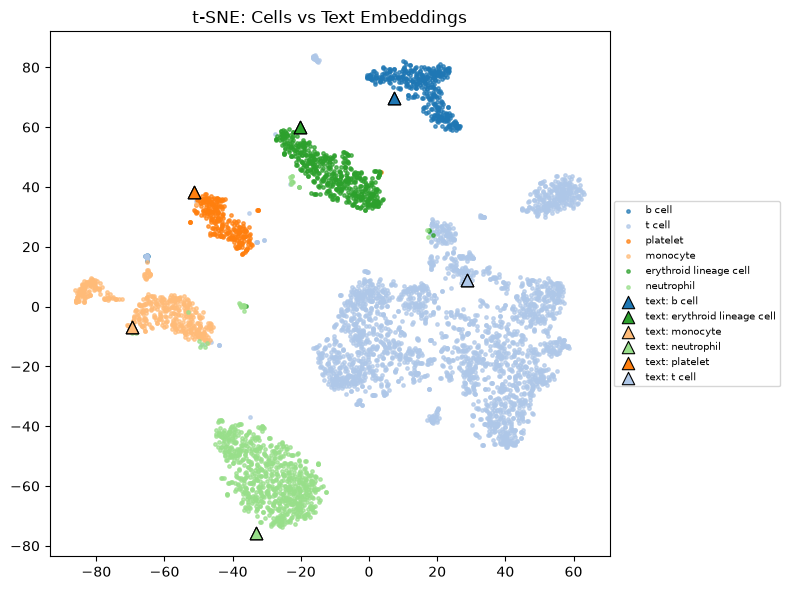

In [3]:
dts_name = "E-MTAB-9221"

# label_col = 'cell_type'  

# ## load data
# adata = sc.read(f'./data/{dts_name}.h5ad')

adata = sc.read('/data/dungp/projects/single-Cell/Sy-Code/code-for-reproducibility/git_repo/seafile_data/scLEAP/data/zero_shot_datasets/E-MTAB-9221.project.h5ad')

label_col = "cell_type"

# Match script behavior: convert labels to lowercase strings
adata.obs[label_col] = adata.obs[label_col].astype(str).str.lower()

# Data normalization if needed
if adata.X.max() > 20:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

cell_types = adata.obs[label_col].unique().tolist()
int_to_ct = {i: ct for i, ct in enumerate(cell_types)}

process_new_celltypes(model, cell_types)

# Extract cell expression embeddings
embeddings = extract_embeddings(adata, model)
embeddings = embeddings.cpu().numpy()

# Normalize expression embeddings, matching the script
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print(embeddings.shape)

dts_save_path = f"./results/zero_shot_annotation/{dts_name}"
os.makedirs(dts_save_path, exist_ok=True)

dts_save_name = dts_name.split("/")[-1]

# Plot t-SNE only
adata_full = plot_embeddings_tsne(
    model,
    adata,
    embeddings,
    int_to_ct,
    cell_types,
    label_col=label_col,
    save_path=None
)

### KNN building and predicting

In [4]:
# Extract cell type text embeddings for prediction
labels = []
text_embeddings = []

with torch.no_grad():
    for _ in range(10):
        model.n_prompts = 5

        lb, t_embeddings = model.get_class_text_centers(
            labels=torch.LongTensor(np.arange(len(cell_types))),
            only_centers=True,
        )

        labels.append(lb)
        text_embeddings.append(t_embeddings)

labels = torch.cat(labels, dim=0)
text_embeddings = torch.cat(text_embeddings, dim=0)

text_embeddings = F.normalize(text_embeddings, dim=-1)

labels = labels.detach().cpu().numpy()
text_embeddings = text_embeddings.detach().cpu().numpy()

adata.obs["cell_type_ols"] = adata.obs[label_col].astype(str)

# Train kNN classifier on text embeddings
clf = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine",
    weights="distance",
)

clf.fit(text_embeddings, labels)

# Match script behavior: re-extract embeddings for prediction
pred_embeddings = extract_embeddings(adata, model).cpu().numpy()
pred_embeddings = pred_embeddings / np.linalg.norm(
    pred_embeddings,
    axis=1,
    keepdims=True,
)

predictions = clf.predict(pred_embeddings)
predictions = np.array([int_to_ct[label] for label in predictions])

y_true = adata.obs["cell_type_ols"].values
y_pred = predictions

report = classification_report(y_true, y_pred, output_dict=False)
print(report)

# Save predictions to an AnnData file
pred_adata = sc.AnnData(X=pred_embeddings, obs=adata.obs.copy())
pred_adata.obs["predicted_cell_type"] = y_pred

pred_adata.write_h5ad(dts_save_path + f"/{dts_save_name}_predictions.h5ad")
print(f"Predictions saved to {dts_save_path + f'/{dts_save_name}_predictions.h5ad'}")

# Save t-SNE and metadata
tsne_df = pd.DataFrame(
    adata_full.obsm["X_tsne"],
    columns=["tsne1", "tsne2"],
)

tsne_df.index = adata_full.obs.index
tsne_df = pd.concat([tsne_df, adata_full.obs], axis=1)

tsne_df.to_csv(
    dts_save_path + f"/{dts_save_name}_tsne.csv",
    index=True,
)

# Save metrics
with open(dts_save_path + "/results.txt", "w") as f:
    f.write(report)

                        precision    recall  f1-score   support

                b cell       0.94      0.98      0.96       385
erythroid lineage cell       0.94      0.99      0.96       485
              monocyte       0.91      1.00      0.95       458
            neutrophil       1.00      0.96      0.98       770
              platelet       0.96      1.00      0.98       259
                t cell       1.00      0.97      0.98      2546

              accuracy                           0.98      4903
             macro avg       0.96      0.98      0.97      4903
          weighted avg       0.98      0.98      0.98      4903

Predictions saved to ./results/zero_shot_annotation/E-MTAB-9221/E-MTAB-9221_predictions.h5ad
